## Amperon Take Home test
Author: Leon Hamnett

### Imports

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holidays
import seaborn as sns
import yaml
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Set filepaths

In [192]:
#set top-level folder
top_level_folder = os.path.abspath(os.getcwd())
cfg_path = os.path.join(top_level_folder,'configs/default.yaml')

with open(cfg_path, 'r') as stream:
    cfg = yaml.safe_load(stream)

if 'top_level_folder_path' in cfg['paths']:
    print(f"Updating top_level_folder_path from {cfg['paths']['top_level_folder_path']} to {top_level_folder}")
else:
    print(f"Setting top_level_folder_path to {top_level_folder}")
    cfg['paths']['top_level_folder_path']  = top_level_folder

with open(cfg_path, 'w') as stream:
    yaml.dump(cfg, stream)

Updating top_level_folder_path from /home/leon/Documents/github_repos/amperon_take_home_test/Amperon_take_home to /home/leon/Documents/github_repos/amperon_take_home_test/Leon_Hamnett_Amperon_take_home


Update data folder paths based on folder location

In [193]:
raw_data_folder_path = os.path.join(top_level_folder,'data/raw')
merged_data_folder_path = os.path.join(top_level_folder,'data/merged')
processed_data_folder_path = os.path.join(top_level_folder,'data/processed')
features_data_folder_path = os.path.join(top_level_folder,'data/features_added')

# Create directories if they don't exist
os.makedirs(raw_data_folder_path, exist_ok=True)
os.makedirs(merged_data_folder_path, exist_ok=True)
os.makedirs(processed_data_folder_path, exist_ok=True)
os.makedirs(features_data_folder_path, exist_ok=True)

#update config file with paths
cfg['paths']['raw_data_folder_path'] = raw_data_folder_path
cfg['paths']['merged_data_folder_path'] = merged_data_folder_path
cfg['paths']['processed_data_folder_path'] = processed_data_folder_path
cfg['paths']['features_data_folder_path'] = features_data_folder_path

with open(cfg_path, 'w') as stream:
    yaml.dump(cfg, stream)



### Load datasets

In [194]:
historical_data_path = os.path.join(raw_data_folder_path,'load_hist_data.csv')
historical_df = pd.read_csv(historical_data_path)
historical_df.head(10)


,Date,Hour,Load
0,1/1/2005,1,857
1,1/1/2005,2,825
2,1/1/2005,3,800
3,1/1/2005,4,794
4,1/1/2005,5,802
5,1/1/2005,6,828
6,1/1/2005,7,870
7,1/1/2005,8,916
8,1/1/2005,9,978
9,1/1/2005,10,988


In [195]:
weather_data_path = os.path.join(raw_data_folder_path,'weather_data.csv')
weather_df = pd.read_csv(weather_data_path)
weather_df.head(10)

,Date,Hour,Station ID,Temperature
0,1/1/2005,1,1,43
1,1/1/2005,2,1,41
2,1/1/2005,3,1,40
3,1/1/2005,4,1,39
4,1/1/2005,5,1,38
5,1/1/2005,6,1,37
6,1/1/2005,7,1,37
7,1/1/2005,8,1,36
8,1/1/2005,9,1,36
9,1/1/2005,10,1,44


In [196]:
# us_holidays_df = pd.read_csv("US Holiday Dates (2004-2021).csv")

# # Convert the 'Date' column to datetime format
# us_holidays_df['Date'] = pd.to_datetime(us_holidays_df['Date'])
# unique_holiday_dates = us_holidays_df['Date'].dt.date.unique()
# unique_holidays = us_holidays_df['Holiday'].unique()
# print(unique_holidays)
# us_holidays_df.tail(10)

### Exploratory analysis

#### EDA historical load data

In [197]:
print(historical_df.info())
historical_df.tail(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26280 entries, 0 to 26279
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    26280 non-null  object
 1   Hour    26280 non-null  int64 
 2   Load    26280 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 616.1+ KB
None


,Date,Hour,Load
26270,12/31/2007,15,898
26271,12/31/2007,16,893
26272,12/31/2007,17,941
26273,12/31/2007,18,1129
26274,12/31/2007,19,1278
26275,12/31/2007,20,1269
26276,12/31/2007,21,1255
26277,12/31/2007,22,1237
26278,12/31/2007,23,1212
26279,12/31/2007,24,1174


In [198]:
historical_df['Load'].describe()

count    26280.000000
mean      1071.858866
std        313.951126
min        509.000000
25%        854.000000
50%       1009.000000
75%       1252.000000
max       2266.000000
Name: Load, dtype: float64

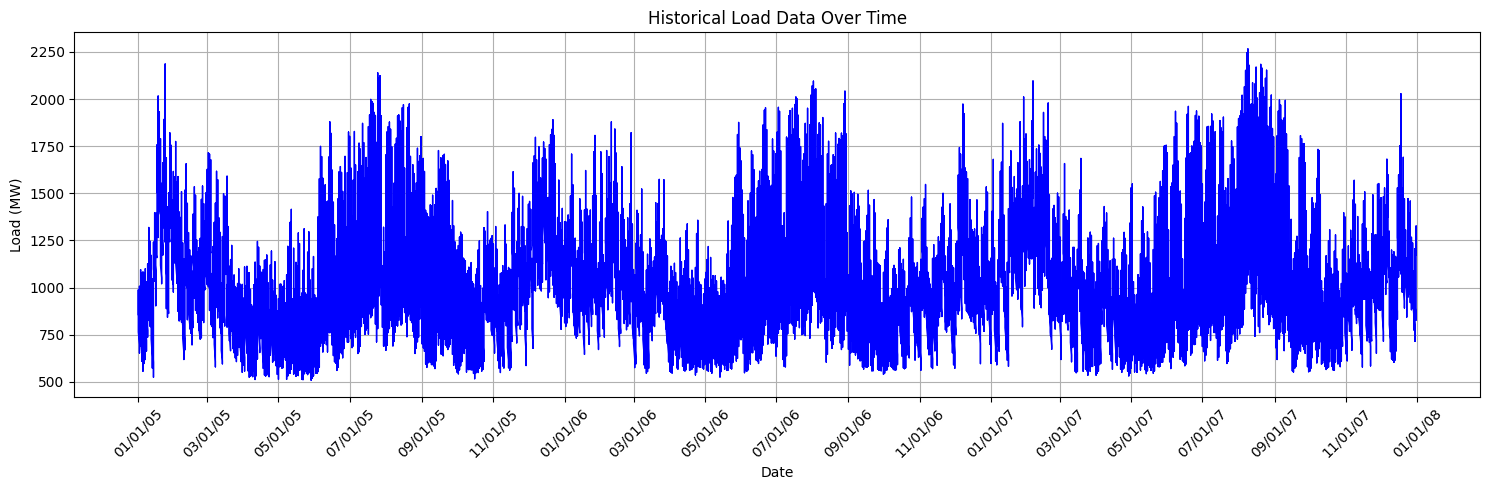

In [199]:

historical_df['Date'] = pd.to_datetime(historical_df['Date'])

def make_time_series_viz(x_vals,y_vals,x_label,y_label,title):
    plt.figure(figsize=(15, 5))  # Increase the figure size for better spacing
    plt.plot(x_vals, y_vals, color='blue', linewidth=1)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%d/%y'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.xticks(rotation=45)  # Rotate xticks for better readability
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.grid(True)
    plt.show()

make_time_series_viz(historical_df['Date'], historical_df['Load'], 'Date', 'Load (MW)', 'Historical Load Data Over Time')




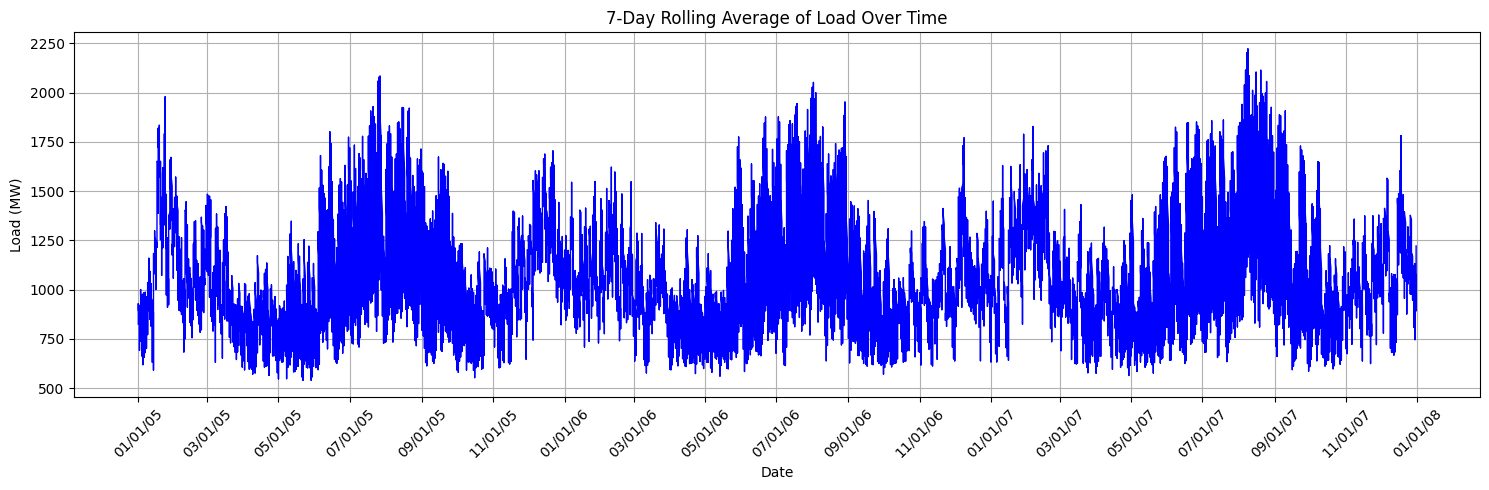

In [200]:
#make load rolling average 7 day
historical_df_rolling = historical_df.copy()
historical_df_rolling['Load_Rolling_Avg_7D'] = historical_df_rolling['Load'].rolling(window=7).mean()
make_time_series_viz(historical_df_rolling['Date'], historical_df_rolling['Load_Rolling_Avg_7D'], 'Date', 'Load (MW)', '7-Day Rolling Average of Load Over Time')

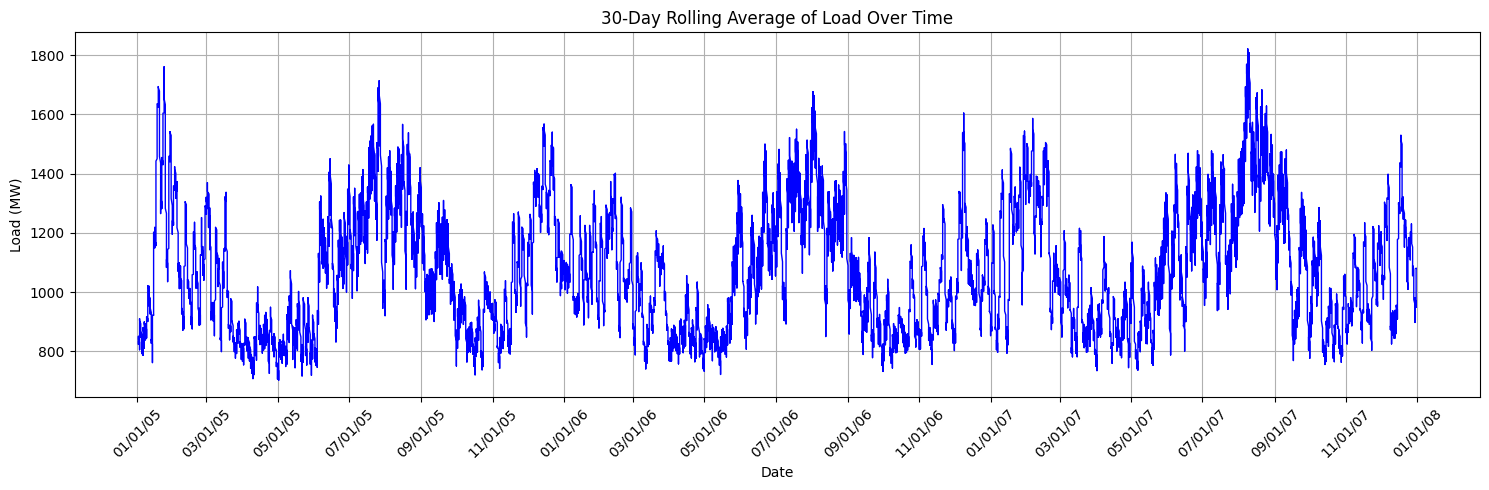

In [201]:
historical_df_rolling['Load_Rolling_Avg_30D'] = historical_df_rolling['Load'].rolling(window=30).mean()
make_time_series_viz(historical_df_rolling['Date'], historical_df_rolling['Load_Rolling_Avg_30D'], 'Date', 'Load (MW)', '30-Day Rolling Average of Load Over Time')

#### EDA weather

In [202]:
print(weather_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981792 entries, 0 to 981791
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Date         981792 non-null  object
 1   Hour         981792 non-null  int64 
 2   Station ID   981792 non-null  int64 
 3   Temperature  981792 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 30.0+ MB
None


In [203]:
weather_df.tail(10)

,Date,Hour,Station ID,Temperature
981782,12/31/2008,15,28,48
981783,12/31/2008,16,28,46
981784,12/31/2008,17,28,42
981785,12/31/2008,18,28,40
981786,12/31/2008,19,28,38
981787,12/31/2008,20,28,36
981788,12/31/2008,21,28,34
981789,12/31/2008,22,28,33
981790,12/31/2008,23,28,31
981791,12/31/2008,24,28,30


In [204]:
weather_df["Station ID"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])

In [205]:
#count entries per station
print(weather_df["Station ID"].value_counts())

Station ID
1     35064
2     35064
3     35064
4     35064
5     35064
6     35064
7     35064
8     35064
9     35064
10    35064
11    35064
12    35064
13    35064
14    35064
15    35064
16    35064
17    35064
18    35064
19    35064
20    35064
21    35064
22    35064
23    35064
24    35064
25    35064
26    35064
27    35064
28    35064
Name: count, dtype: int64


<Axes: title={'center': 'Temperature'}, xlabel='Station ID'>

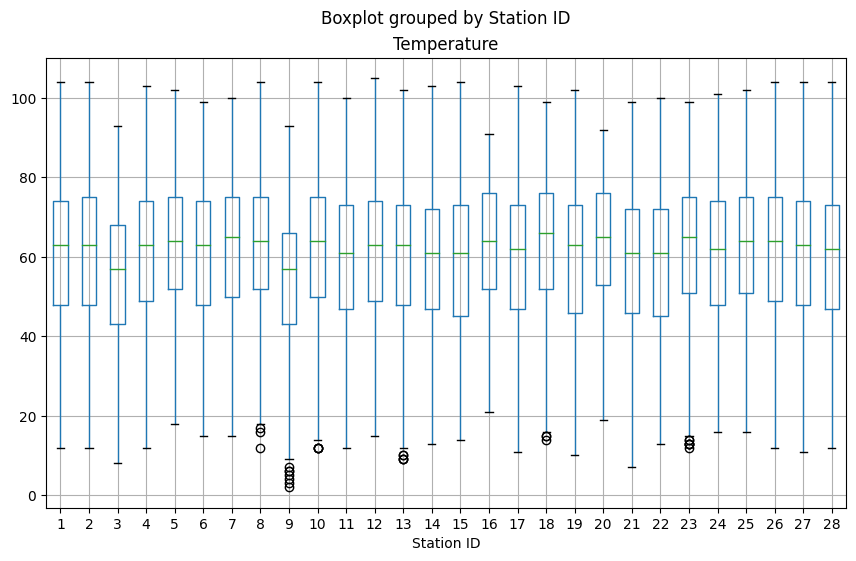

In [206]:
#show box plots of temperature per station
weather_df.boxplot(column='Temperature', by='Station ID', figsize=(10, 6))

In [207]:
#check if any station is significantly different in temperature distribution
import scipy.stats as stats
stations = weather_df["Station ID"].unique()
station_temps = [weather_df[weather_df["Station ID"] == station]["Temperature"] for station in stations]
f_stat, p_val = stats.f_oneway(*station_temps)
print(f"ANOVA F-statistic: {f_stat}, p-value: {p_val}")

#make kruskal wallis test
h_stat, p_val = stats.kruskal(*station_temps)
print(f"Kruskal-Wallis H-statistic: {h_stat}, p-value: {p_val}")



ANOVA F-statistic: 655.0307201911685, p-value: 0.0
Kruskal-Wallis H-statistic: 16317.008491219452, p-value: 0.0


ANOVA < 0.05 : reject null that means are the same
Kruskal-Wallis < 0.05 - reject null

In [208]:
# #make time series viz of temp per station
# weather_df['Date'] = pd.to_datetime(weather_df['Date'])
# station_ids = weather_df['Station ID'].unique()
# for station_id in station_ids:
#     station_data = weather_df[weather_df['Station ID'] == station_id]
#     make_time_series_viz(station_data['Date'], station_data['Temperature'], 'Date', 'Temperature (°F)', f'Temperature Over Time at Station {station_id}')


### Combine datasets

Pivot weather data to have temp reading per hour for all weather stations

In [209]:
pivot_weather_data_code_path = os.path.join(top_level_folder,'src/process_data/pivot_weather_data.py')
os.system(f'python {pivot_weather_data_code_path}')
print('weather data pivoted')

weather data pivoted


Traceback (most recent call last):
  File "/home/leon/Documents/github_repos/amperon_take_home_test/Leon_Hamnett_Amperon_take_home/src/process_data/pivot_weather_data.py", line 14, in <module>
    weather_df = pd.read_csv(weather_csv_path)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 948, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 611, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1448, in __init__
    self._engine = self._make_engine(f, self.engine)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1705, in _make_engine
    self.handles = get_handle(
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/

In [210]:
weather_df_pivot = pd.read_csv('data/processed/pivoted_weather_data.csv')

weather_df_pivot.head(10)
weather_df_pivot.tail(10)


,Date,Hour,temp_station_1,temp_station_2,temp_station_3,temp_station_4,temp_station_5,temp_station_6,temp_station_7,temp_station_8,...,temp_station_19,temp_station_20,temp_station_21,temp_station_22,temp_station_23,temp_station_24,temp_station_25,temp_station_26,temp_station_27,temp_station_28
35050,9/9/2008,15,86,88,70,84,82,88,84,81,...,84,83,77,73,84,89,91,88,86,85
35051,9/9/2008,16,86,89,72,82,82,88,87,82,...,84,84,75,75,82,87,84,86,84,82
35052,9/9/2008,17,84,89,74,82,84,88,84,82,...,77,82,73,75,80,87,75,85,84,83
35053,9/9/2008,18,81,89,75,82,82,85,81,84,...,73,82,73,73,82,80,75,79,84,81
35054,9/9/2008,19,77,87,73,81,81,81,78,82,...,75,81,73,73,81,79,73,79,81,75
35055,9/9/2008,20,73,83,71,77,77,79,77,79,...,73,81,72,72,79,78,72,77,77,73
35056,9/9/2008,21,73,79,70,77,77,79,73,79,...,72,81,70,72,76,77,79,76,75,72
35057,9/9/2008,22,72,78,67,76,77,76,72,79,...,72,76,70,72,75,76,80,77,75,71
35058,9/9/2008,23,72,76,66,74,77,75,71,77,...,72,72,70,72,75,76,79,75,74,71
35059,9/9/2008,24,72,75,66,73,77,75,71,73,...,72,73,70,72,75,76,78,75,75,70


Join weather and historical load data

In [211]:
combine_data_code_path = os.path.join(top_level_folder,'src/process_data/combine_datasets.py')
os.system(f'python {combine_data_code_path}')

combined_df = pd.read_csv('data/merged/combined_data.csv')
combined_df.head(10)

Traceback (most recent call last):
  File "/home/leon/Documents/github_repos/amperon_take_home_test/Leon_Hamnett_Amperon_take_home/src/process_data/combine_datasets.py", line 15, in <module>
    weather_df_pivot = pd.read_csv(pivoted_weather_csv_path)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 948, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 611, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1448, in __init__
    self._engine = self._make_engine(f, self.engine)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1705, in _make_engine
    self.handles = get_handle(
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-pack

,Date,Hour,Load,temp_station_1,temp_station_2,temp_station_3,temp_station_4,temp_station_5,temp_station_6,temp_station_7,...,temp_station_19,temp_station_20,temp_station_21,temp_station_22,temp_station_23,temp_station_24,temp_station_25,temp_station_26,temp_station_27,temp_station_28
0,2005-01-01,1,857.0,43,46,40,47,48,46,44,...,39,50,43,45,50,47,41,47,47,45
1,2005-01-01,2,825.0,41,46,38,46,48,45,51,...,41,49,43,46,47,47,45,47,47,45
2,2005-01-01,3,800.0,40,46,37,45,45,45,49,...,43,50,41,45,45,46,45,46,46,43
3,2005-01-01,4,794.0,39,46,37,47,48,48,45,...,43,49,41,43,45,44,45,47,47,44
4,2005-01-01,5,802.0,38,46,37,44,48,49,43,...,43,49,39,43,43,45,45,47,46,44
5,2005-01-01,6,828.0,37,45,36,45,48,48,40,...,39,45,39,46,41,48,46,44,46,42
6,2005-01-01,7,870.0,37,45,37,45,48,44,41,...,39,44,39,45,44,47,45,47,47,42
7,2005-01-01,8,916.0,36,43,37,43,48,48,43,...,39,51,39,45,47,49,46,45,47,41
8,2005-01-01,9,978.0,36,52,38,49,48,51,51,...,43,53,43,52,51,51,54,48,48,48
9,2005-01-01,10,988.0,44,55,43,55,55,55,56,...,54,58,52,57,56,55,55,53,54,53


In [212]:
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df['day_of_week'] = combined_df['Date'].dt.dayofweek
combined_df['month'] = combined_df['Date'].dt.month
combined_df['year'] = combined_df['Date'].dt.year

combined_df.head(10)

,Date,Hour,Load,temp_station_1,temp_station_2,temp_station_3,temp_station_4,temp_station_5,temp_station_6,temp_station_7,...,temp_station_22,temp_station_23,temp_station_24,temp_station_25,temp_station_26,temp_station_27,temp_station_28,day_of_week,month,year
0,2005-01-01,1,857.0,43,46,40,47,48,46,44,...,45,50,47,41,47,47,45,5,1,2005
1,2005-01-01,2,825.0,41,46,38,46,48,45,51,...,46,47,47,45,47,47,45,5,1,2005
2,2005-01-01,3,800.0,40,46,37,45,45,45,49,...,45,45,46,45,46,46,43,5,1,2005
3,2005-01-01,4,794.0,39,46,37,47,48,48,45,...,43,45,44,45,47,47,44,5,1,2005
4,2005-01-01,5,802.0,38,46,37,44,48,49,43,...,43,43,45,45,47,46,44,5,1,2005
5,2005-01-01,6,828.0,37,45,36,45,48,48,40,...,46,41,48,46,44,46,42,5,1,2005
6,2005-01-01,7,870.0,37,45,37,45,48,44,41,...,45,44,47,45,47,47,42,5,1,2005
7,2005-01-01,8,916.0,36,43,37,43,48,48,43,...,45,47,49,46,45,47,41,5,1,2005
8,2005-01-01,9,978.0,36,52,38,49,48,51,51,...,52,51,51,54,48,48,48,5,1,2005
9,2005-01-01,10,988.0,44,55,43,55,55,55,56,...,57,56,55,55,53,54,53,5,1,2005


#### EDA on combined dataset

Exploring important features on Load - may help build predictive model for peak hour

In [213]:
combined_df.corr()['Load'].sort_values(ascending=False)


Load               1.000000
Hour               0.401753
temp_station_1     0.175192
temp_station_22    0.167564
temp_station_19    0.161180
temp_station_14    0.161054
temp_station_15    0.160944
temp_station_17    0.160111
temp_station_21    0.159236
temp_station_27    0.157471
temp_station_28    0.156455
temp_station_2     0.155153
temp_station_4     0.152712
temp_station_12    0.152462
temp_station_3     0.151330
temp_station_10    0.150746
temp_station_11    0.150124
temp_station_5     0.145990
temp_station_25    0.143774
temp_station_26    0.143650
temp_station_8     0.141969
temp_station_13    0.139484
temp_station_24    0.134573
temp_station_6     0.126355
temp_station_7     0.119037
temp_station_9     0.118401
temp_station_23    0.111671
temp_station_18    0.108015
temp_station_16    0.103495
temp_station_20    0.085618
Date               0.057474
year               0.048800
month              0.031689
day_of_week       -0.065652
Name: Load, dtype: float64

Exploring variation in load based on time

<Axes: xlabel='Hour', ylabel='Load'>

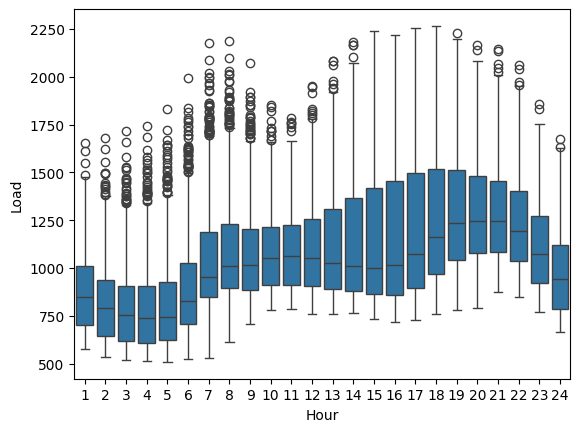

In [214]:
sns.boxplot(x='Hour', y='Load', data=combined_df)


<Axes: xlabel='day_of_week', ylabel='Load'>

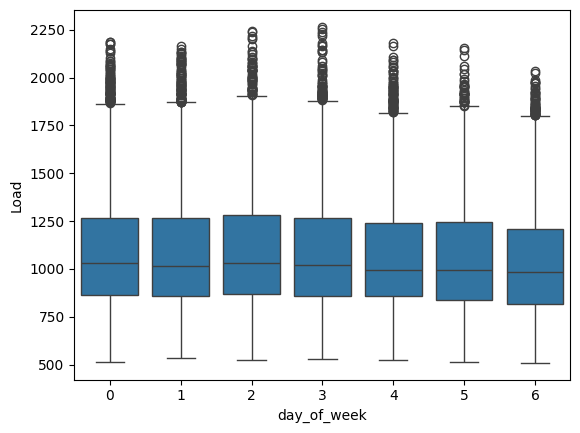

In [215]:
sns.boxplot(x='day_of_week', y='Load', data=combined_df)

<Axes: xlabel='month', ylabel='Load'>

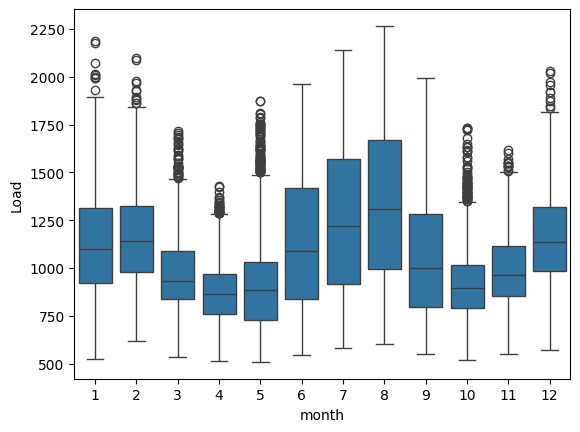

In [216]:
sns.boxplot(x='month', y='Load', data=combined_df)

<Axes: xlabel='year', ylabel='Load'>

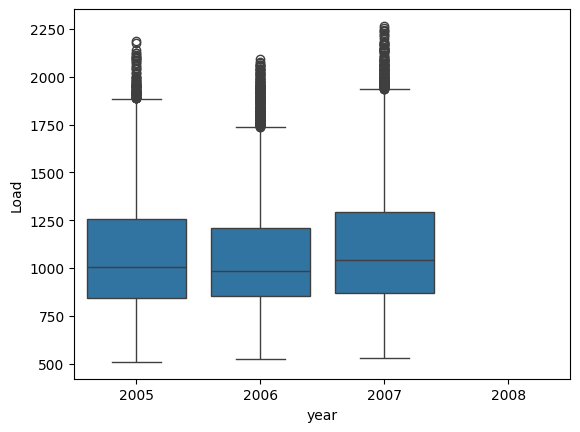

In [217]:
sns.boxplot(x='year', y='Load', data=combined_df)

Exploring prior probabilities

In [218]:
def make_highest_daily_load_feature(df):
    df = df.copy()
    df['is_peak_hour_per_day'] = df.groupby('Date')['Load'].transform(lambda x: x == x.max())
    df['is_peak_hour_per_day'] = df['is_peak_hour_per_day'].astype(int)
    return df

def make_simple_ranking_feature(df):
    df = df.copy()
    df['hourly_load_rank_per_day'] = df.groupby('Date')['Load'].rank(ascending=False, method='min')
    return df

def make_simple_probability(df):

    df = df.copy()

    # Calculate historical P(peak | hour)
    hour_peak_prob = df.groupby('Hour')['is_peak_hour_per_day'].mean()
    #normalise to sum to 1
    hour_peak_prob = hour_peak_prob / hour_peak_prob.sum()
    df['hour_peak_prob'] = df['Hour'].map(hour_peak_prob)

    return hour_peak_prob,df

def make_probability_with_rank(df):
    """
    Estimate a simple probability that each hour is the daily peak,
    based on the *average within-day load rank* across history.

    Assumes:
        - 'Hour' column (1-24)
        - 'hourly_load_rank_per_day' column (1 = highest load, 24 = lowest)

    Returns:
        DataFrame with new column 'hour_rank_peak_prob'
    """

    df = df.copy()

    # 1. Compute average rank per hour across all days
    avg_rank_per_hour = df.groupby('Hour')['hourly_load_rank_per_day'].mean() #higher mean = lower chance

    #convert so higher is better
    avg_rank_per_hour_inv = 1/avg_rank_per_hour

    #norm
    avg_rank_per_hour_inv_norm = avg_rank_per_hour_inv / avg_rank_per_hour_inv.sum()


    # 4. Map back to dataframe
    df['hour_rank_peak_prob'] = df['Hour'].map(avg_rank_per_hour_inv_norm)

    return avg_rank_per_hour_inv_norm,df

simple_train_df = combined_df[combined_df['year'].isin([2005,2006])]
simple_train_df = make_highest_daily_load_feature(simple_train_df)
simple_train_df = make_simple_ranking_feature(simple_train_df)


simple_hour_prob_table_train,simple_train_df = make_simple_probability(simple_train_df)
rank_based_prob_table_train,simple_train_df = make_probability_with_rank(simple_train_df)




In [219]:
def make_prob_graph(probs, title, xlabel, y_label):
    plt.figure(figsize=(10, 6))
    plt.plot(probs.index, probs.values, marker='x')
    plt.title(title)
    plt.xticks(range(1, 25))
    plt.xlabel(xlabel)
    plt.ylabel(y_label)
    # plt.ylim(0, 0.3)  # Adjust y-axis limit for better visibility
    plt.grid(True)
    plt.show()



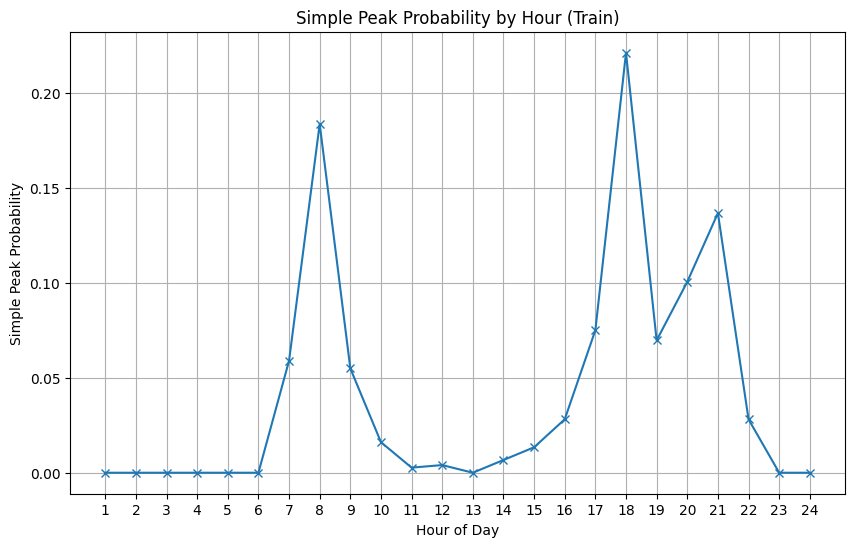

In [220]:
make_prob_graph(simple_hour_prob_table_train, 'Simple Peak Probability by Hour (Train)', 'Hour of Day', 'Simple Peak Probability')

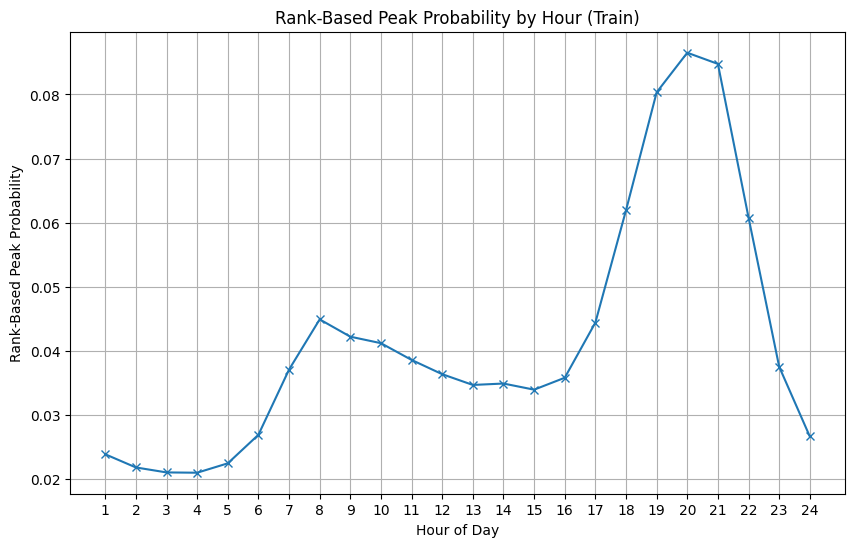

In [221]:
make_prob_graph(rank_based_prob_table_train, 'Rank-Based Peak Probability by Hour (Train)', 'Hour of Day', 'Rank-Based Peak Probability')


### Feature Engineering

Now we have the combined datasets, we engineer new features across all years being careful that information is not leaked across years (since we will make train/val/test splits based on year). 

We convert hour,day of week, month to cyclical encoding to help the model better understand that monday is close to sunday, or january is close to december. 

We add in information related to public holidays (name, type of holiday etc).

We add summary statistics per hour for the temperature readings from the various stations - eg max temp, min temp, mean temps etc. 

Several variables (['season', 'holiday_type','holiday_name']) are converted to one-hot encoding to act as binary flags eg holiday_is_christmas. 

In [222]:
engineer_features_code_path = os.path.join(top_level_folder,'src/process_data/engineer_input_features.py')
os.system(f'python {engineer_features_code_path}')
print('dataset with engineered features created')
engineered_df = pd.read_csv('data/features_added/engineered_features_data.csv')
print(engineered_df.columns)


dataset with engineered features created
Index(['Date', 'Hour', 'Load', 'temp_station_1', 'temp_station_2',
       'temp_station_3', 'temp_station_4', 'temp_station_5', 'temp_station_6',
       'temp_station_7', 'temp_station_8', 'temp_station_9', 'temp_station_10',
       'temp_station_11', 'temp_station_12', 'temp_station_13',
       'temp_station_14', 'temp_station_15', 'temp_station_16',
       'temp_station_17', 'temp_station_18', 'temp_station_19',
       'temp_station_20', 'temp_station_21', 'temp_station_22',
       'temp_station_23', 'temp_station_24', 'temp_station_25',
       'temp_station_26', 'temp_station_27', 'temp_station_28', 'day_of_week',
       'month', 'day_of_month', 'is_weekend', 'day_of_week_sin',
       'day_of_week_cos', 'month_sin', 'month_cos', 'hour_sin', 'hour_cos',
       'is_holiday', 'time_to_next_holiday', 'time_since_last_holiday',
       'max_station_temp', 'min_station_temp', 'mean_station_temp',
       'std_station_temp', 'temp_diff_stations', 'sea

Traceback (most recent call last):
  File "/home/leon/Documents/github_repos/amperon_take_home_test/Leon_Hamnett_Amperon_take_home/src/process_data/engineer_input_features.py", line 143, in <module>
    merged_df = pd.read_csv(merged_dataset_path)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 948, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 611, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1448, in __init__
    self._engine = self._make_engine(f, self.engine)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1705, in _make_engine
    self.handles = get_handle(
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages

### Making train/val/test splits

Now that we have engineered the various features, we split the data into train/val/testing. 
We choose the years 2005,2006 as training data, 2007 as validation data, and 2008 as out testing data. We will train and iterate models and hyperparameters to improve predictive performance on the validation set. Once we are happy with the results and training porcess, we will combine the validation set back into the training set, run the final training and then make our final predictions against the test set. 

We fit a scaler based on the training set, then apply to the validation and test sets. We also add a feature related to the prior probabilities of a specific hour being a peak hour based on the training set - the intuition being that this will serve to guide the model to more successful predictions.

We convert the hourly data into daily blocks, so that the target is [n x 24] one-hot vector indicating which hour was the hour with the peak load.

In [223]:
make_splits_code_path = os.path.join(top_level_folder,'src/process_data/make_train_val_test_splits.py')
os.system(f'python {make_splits_code_path}')

making train, val, test splits


Traceback (most recent call last):
  File "/home/leon/Documents/github_repos/amperon_take_home_test/Leon_Hamnett_Amperon_take_home/src/process_data/make_train_val_test_splits.py", line 63, in <module>
    engineered_features_df = pd.read_csv(engineered_features_path)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 948, in read_csv
    return _read(filepath_or_buffer, kwds)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 611, in _read
    parser = TextFileReader(filepath_or_buffer, **kwds)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1448, in __init__
    self._engine = self._make_engine(f, self.engine)
  File "/home/leon/.conda/envs/ml_general/lib/python3.10/site-packages/pandas/io/parsers/readers.py", line 1705, in _make_engine
    self.handles = get_handle(
  File "/home/leon/.conda/envs/ml_general/lib/pyth

256

In [224]:
train_x = pd.read_csv('data/splits/train_x.csv')
for col in train_x.columns:
    print(col)

Unnamed: 0
temp_station_1_hour_1
temp_station_2_hour_1
temp_station_3_hour_1
temp_station_4_hour_1
temp_station_5_hour_1
temp_station_6_hour_1
temp_station_7_hour_1
temp_station_8_hour_1
temp_station_9_hour_1
temp_station_10_hour_1
temp_station_11_hour_1
temp_station_12_hour_1
temp_station_13_hour_1
temp_station_14_hour_1
temp_station_15_hour_1
temp_station_16_hour_1
temp_station_17_hour_1
temp_station_18_hour_1
temp_station_19_hour_1
temp_station_20_hour_1
temp_station_21_hour_1
temp_station_22_hour_1
temp_station_23_hour_1
temp_station_24_hour_1
temp_station_25_hour_1
temp_station_26_hour_1
temp_station_27_hour_1
temp_station_28_hour_1
day_of_week_hour_1
month_hour_1
day_of_month_hour_1
is_weekend_hour_1
day_of_week_sin_hour_1
day_of_week_cos_hour_1
month_sin_hour_1
month_cos_hour_1
is_holiday_hour_1
time_to_next_holiday_hour_1
time_since_last_holiday_hour_1
max_station_temp_hour_1
min_station_temp_hour_1
mean_station_temp_hour_1
std_station_temp_hour_1
temp_diff_stations_hour_1
seas

In [225]:

# def map_one_hot_to_int(df):
#     """
#     Convert one-hot encoded y_ columns into a single integer column 'y_peak_hour'.
#     """
#     # Identify one-hot columns

    
#     # Argmax across the one-hot columns to find the peak hour
#     df['y_peak_hour'] = df['y_vector'].argmax(axis=1).astype(int)
    
#     # Optionally drop the original one-hot columns
#     # df = df.drop(columns=y_cols)
    
#     return df


# train_y = combine_y_columns(train_y)
# # train_df_with_y = one_hot_to_int(train_df_with_y)

# train_y.head()


### Model Training

In [226]:
def combine_y_columns(df, y_prefix='target_hour'):
    """Combine one-hot columns (e.g., target_hour0..23) into a per-row np.ndarray."""
    y_cols = [c for c in df.columns if c.startswith(y_prefix)]
    if not y_cols:
        raise ValueError(f"No columns found starting with prefix '{y_prefix}'")
    # Ensure numeric, coerce bad values to 0, then int
    df[y_cols] = df[y_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)
    df['y_vector'] = df[y_cols].apply(lambda r: np.array(r.to_numpy(), dtype=int), axis=1)
    return df


In [227]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

In [228]:
# --- Load data ---
train_x = pd.read_csv(os.path.join(top_level_folder,'data/splits/train_x.csv'))
train_y = pd.read_csv(os.path.join(top_level_folder,'data/splits/train_y.csv'))
val_x   = pd.read_csv(os.path.join(top_level_folder,'data/splits/val_x.csv'))
val_y   = pd.read_csv(os.path.join(top_level_folder,'data/splits/val_y.csv'))

for col in train_x.columns:
    print(col)

Unnamed: 0
temp_station_1_hour_1
temp_station_2_hour_1
temp_station_3_hour_1
temp_station_4_hour_1
temp_station_5_hour_1
temp_station_6_hour_1
temp_station_7_hour_1
temp_station_8_hour_1
temp_station_9_hour_1
temp_station_10_hour_1
temp_station_11_hour_1
temp_station_12_hour_1
temp_station_13_hour_1
temp_station_14_hour_1
temp_station_15_hour_1
temp_station_16_hour_1
temp_station_17_hour_1
temp_station_18_hour_1
temp_station_19_hour_1
temp_station_20_hour_1
temp_station_21_hour_1
temp_station_22_hour_1
temp_station_23_hour_1
temp_station_24_hour_1
temp_station_25_hour_1
temp_station_26_hour_1
temp_station_27_hour_1
temp_station_28_hour_1
day_of_week_hour_1
month_hour_1
day_of_month_hour_1
is_weekend_hour_1
day_of_week_sin_hour_1
day_of_week_cos_hour_1
month_sin_hour_1
month_cos_hour_1
is_holiday_hour_1
time_to_next_holiday_hour_1
time_since_last_holiday_hour_1
max_station_temp_hour_1
min_station_temp_hour_1
mean_station_temp_hour_1
std_station_temp_hour_1
temp_diff_stations_hour_1
seas

In [229]:
# --- Build y as stacked (n_days, 24) float32 arrays ---
train_y = combine_y_columns(train_y, y_prefix='target_hour')
val_y   = combine_y_columns(val_y,   y_prefix='target_hour')

y_train = np.stack(train_y['y_vector'].to_numpy()).astype(np.float32)  # (n_days, 24)
y_val   = np.stack(val_y['y_vector'].to_numpy()).astype(np.float32)    # (n_days, 24)

# --- Build X as numeric float32 matrices ---
# Drop junk index col if present and keep only numeric cols
train_x = train_x.drop(columns=['Unnamed: 0'], errors='ignore').select_dtypes(include=[np.number])
val_x   = val_x.drop(columns=['Unnamed: 0'],   errors='ignore').select_dtypes(include=[np.number])

X_train = train_x.to_numpy(dtype=np.float32)
X_val   = val_x.to_numpy(dtype=np.float32)

#checks
assert X_train.ndim == 2 and X_train.dtype != object
assert X_val.ndim   == 2 and X_val.dtype   != object
assert y_train.ndim == 2 and y_train.shape[1] == 24 and y_train.dtype != object
assert y_val.ndim   == 2 and y_val.shape[1]   == 24 and y_val.dtype   != object

In [230]:
print(f"Training X shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"Training y shape: {y_train.shape}, dtype: {y_train.dtype}")
print(f"Validation X shape: {X_val.shape}, dtype: {X_val.dtype}")
print(f"Validation y shape: {y_val.shape}, dtype: {y_val.dtype}")
print("First y row:", y_train[0])


Training X shape: (725, 1080), dtype: float32
Training y shape: (725, 24), dtype: float32
Validation X shape: (362, 1080), dtype: float32
Validation y shape: (362, 24), dtype: float32
First y row: [0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [231]:
# Build the model
def build_model(T=1.0):
    inputs = keras.Input(shape=(train_x.shape[1],))
    x = layers.Dense(512, activation='relu')(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    logits = layers.Dense(24)(x)                         # no activation
    outputs = layers.Activation(lambda z: tf.nn.softmax(z / T))(logits)
    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss=keras.losses.CategoricalCrossentropy(from_logits=False,label_smoothing=0.05),
        metrics=['accuracy']
    )
    return model


model = build_model()

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 1080)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 512)            │       553,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 24)             │         3,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 24)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 720,792 (2.75 MB)

 Trainable params: 720,792 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

In [232]:
model = build_model(T=1.5)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)
#training
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1,
    validation_steps=10
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1379 - loss: 4.7349 - val_accuracy: 0.1281 - val_loss: 2.7240
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1752 - loss: 2.8101 - val_accuracy: 0.3250 - val_loss: 2.3412
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2455 - loss: 2.5455 - val_accuracy: 0.3313 - val_loss: 2.4092
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2814 - loss: 2.4143 - val_accuracy: 0.4375 - val_loss: 2.1326
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3352 - loss: 2.2859 - val_accuracy: 0.4125 - val_loss: 2.0467
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3462 - loss: 2.2283 - val_accuracy: 0.4125 - val_loss: 1.9601
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3531 - loss: 2.1528 - val_accuracy: 0.4062 - val_loss: 2.0142
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3931 - loss: 2.0886 - val_accuracy: 0.4281 - 

### Evaluation against val set

In [233]:
# make preds
y_val_preds = model.predict(X_val)  # (n_days, 24) float32 probabilities


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [234]:
y_val_preds_flatten = y_val_preds.flatten() #one pred per hour
y_val_true_flat = y_val.flatten()

print(np.shape(y_val_preds_flatten))
print(np.shape(y_val_true_flat))


(8688,)
(8688,)


In [235]:
#calc error score from arrays
def calc_error_score(y_true, y_pred):
    """
    Score = (p-a)^2
    """
    diff_array = (y_pred - y_true) **2
    total_score = np.sum(diff_array)

    return total_score

print(calc_error_score(y_val_true_flat,y_val_preds_flatten))


251.82831


### Train on combined train + validation set to get predictions against test set

In [236]:
#make combined sets for training 
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.vstack([y_train, y_val])



In [237]:
#load test data to make predictions against
test_x = pd.read_csv(os.path.join(top_level_folder,'data/splits/test_x.csv'),index_col=0)
# test_x['Date'] = pd.to_datetime(test_x['Date'])
# test_x.index = test_x['Date']
test_x   = test_x.drop(columns=['Unnamed: 0'],   errors='ignore').select_dtypes(include=[np.number])
test_days = test_x.index

In [238]:
test_x.head()

,temp_station_1_hour_1,temp_station_2_hour_1,temp_station_3_hour_1,temp_station_4_hour_1,temp_station_5_hour_1,temp_station_6_hour_1,temp_station_7_hour_1,temp_station_8_hour_1,temp_station_9_hour_1,temp_station_10_hour_1,...,month_cos_hour_24,is_holiday_hour_24,time_to_next_holiday_hour_24,time_since_last_holiday_hour_24,max_station_temp_hour_24,min_station_temp_hour_24,mean_station_temp_hour_24,std_station_temp_hour_24,temp_diff_stations_hour_24,prior_probs_hour_24
2008-01-01,0.377778,0.260870,0.297619,0.321839,0.283951,0.4000,0.250000,0.304348,0.379310,0.306818,...,0.866025,1,0.0,0,0.268293,0.158537,0.239130,0.349620,0.588235,0.0
2008-01-02,0.222222,0.271739,0.154762,0.218391,0.234568,0.2375,0.273810,0.271739,0.126437,0.284091,...,0.866025,0,19.0,1,0.146341,0.073171,0.134783,0.313988,0.500000,0.0
2008-01-03,0.166667,0.195652,0.071429,0.126437,0.148148,0.1875,0.154762,0.173913,0.068966,0.170455,...,0.866025,0,18.0,2,0.109756,0.146341,0.077826,0.179276,0.235294,0.0
2008-01-04,0.066667,0.065217,0.095238,0.126437,0.037037,0.0750,0.059524,0.097826,0.137931,0.102273,...,0.866025,0,17.0,3,0.170732,0.195122,0.164783,0.179801,0.264706,0.0
2008-01-05,0.144444,0.173913,0.273810,0.195402,0.086420,0.1750,0.083333,0.173913,0.275862,0.136364,...,0.866025,0,16.0,4,0.390244,0.365854,0.360870,0.144807,0.382353,0.0


In [239]:
# Check for gaps in test dates
test_x.index = pd.to_datetime(test_x.index, format='%Y-%m-%d')
test_dates = pd.to_datetime(np.unique(test_x.index.date))
test_dates_sorted = sorted(test_dates)

# Find missing dates
date_range = pd.date_range(start=min(test_dates_sorted), 
                          end=max(test_dates_sorted), 
                          freq='D')
missing_dates = date_range.difference(pd.to_datetime(test_dates_sorted))
#convert to words

missing_dates = missing_dates.strftime('%d-%b-%Y')
print(f"Missing dates in test set: {missing_dates}")

Missing dates in test set: Index(['09-Mar-2008'], dtype='object')


In [240]:
X_test = test_x.to_numpy(dtype=np.float32)

In [241]:
model = build_model()

# Define callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)


# Train the model
history = model.fit(
    X_train_val, y_train_val,
    epochs=100,
    batch_size=32,
    # validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1,
    # validation_steps=10
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1444 - loss: 4.6439    
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2447 - loss: 2.6802
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2971 - loss: 2.3961
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3321 - loss: 2.2631
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3717 - loss: 2.1682
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3643 - loss: 2.0978
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4305 - loss: 1.9736
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4121 - loss: 2.0005
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4112 - loss: 1.9926
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4250 - loss: 1.9276
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4333 - loss: 1.9162
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accur

In [242]:
#predictions against test set
y_test_preds = model.predict(X_test)
y_test_preds_flat = y_test_preds.flatten()
print(y_test_preds_flat.shape)
print(y_test_preds_flat[0:15])

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
(8736,)
[0.0019463  0.00200716 0.00177645 0.0022791  0.00141263 0.00104353
 0.00327958 0.18732925 0.00120463 0.00309392 0.00285395 0.00207393
 0.00140114 0.00035499 0.00053061]


In [243]:
#make dataframe for test preds
test_preds_df = pd.DataFrame({'Date': np.repeat(test_days, 24),
                         'Hour': list(range(1, 25)) * len(test_days),
                         'Predicted_Probability': y_test_preds_flat})

test_preds_df.head()

,Date,Hour,Predicted_Probability
0,2008-01-01,1,0.001946
1,2008-01-01,2,0.002007
2,2008-01-01,3,0.001776
3,2008-01-01,4,0.002279
4,2008-01-01,5,0.001413


In [244]:
#load output file
probability_estimates_csv_path = os.path.join(top_level_folder,'data/predictions/probability_estimates_empty.csv')
probs_est_df = pd.read_csv(probability_estimates_csv_path)

probs_est_df.head()

,Date,Hour,Daily Peak Probability
0,1/1/2008,1,NaN
1,1/1/2008,2,NaN
2,1/1/2008,3,NaN
3,1/1/2008,4,NaN
4,1/1/2008,5,NaN


In [245]:
#make combined df
probs_est_df['Date'] = pd.to_datetime(probs_est_df['Date'], format='%m/%d/%Y')
test_preds_df['Date'] = pd.to_datetime(test_preds_df['Date'])

probs_est_df['Hour'] = probs_est_df['Hour'].astype(int)
test_preds_df['Hour'] = test_preds_df['Hour'].astype(int)


combined_output = probs_est_df.merge(
    test_preds_df.rename(columns={'Predicted_Probability':'Predicted_Probability_model'}),
    on=['Date','Hour'],
    how='left'
)


combined_output.head()


,Date,Hour,Daily Peak Probability,Predicted_Probability_model
0,2008-01-01,1,NaN,0.001946
1,2008-01-01,2,NaN,0.002007
2,2008-01-01,3,NaN,0.001776
3,2008-01-01,4,NaN,0.002279
4,2008-01-01,5,NaN,0.001413


In [246]:
combined_output["Daily Peak Probability"] = combined_output['Predicted_Probability_model']
#change nan to zero
combined_output['Daily Peak Probability'] = combined_output['Daily Peak Probability'].fillna(0)

In [247]:
#
combined_output[combined_output['Date']=='2008-03-09']

,Date,Hour,Daily Peak Probability,Predicted_Probability_model
1632,2008-03-09,1,0.0,NaN
1633,2008-03-09,3,0.0,NaN
1634,2008-03-09,4,0.0,NaN
1635,2008-03-09,5,0.0,NaN
1636,2008-03-09,6,0.0,NaN
1637,2008-03-09,7,0.0,NaN
1638,2008-03-09,8,0.0,NaN
1639,2008-03-09,9,0.0,NaN
1640,2008-03-09,10,0.0,NaN
1641,2008-03-09,11,0.0,NaN


In [248]:
combined_output = combined_output[["Date", "Hour", "Daily Peak Probability"]]
combined_output.head(24)

,Date,Hour,Daily Peak Probability
0,2008-01-01,1,0.001946
1,2008-01-01,2,0.002007
2,2008-01-01,3,0.001776
3,2008-01-01,4,0.002279
4,2008-01-01,5,0.001413
5,2008-01-01,6,0.001044
6,2008-01-01,7,0.003280
7,2008-01-01,8,0.187329
8,2008-01-01,9,0.001205
9,2008-01-01,10,0.003094


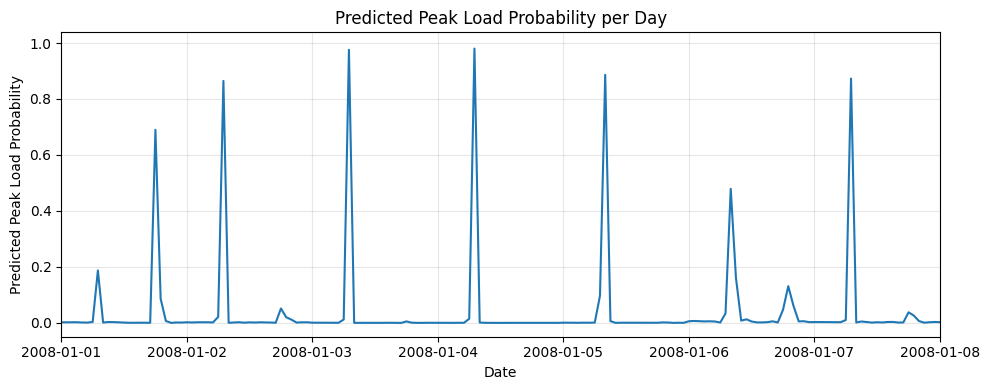

In [249]:
def plot_daily_peak_probabilities(df,x_start,x_end):
    """
    Plots the maximum predicted probability per day as a line graph.
    Assumes df has columns: 'Date', 'Hour', 'Daily Peak Probability'
    """
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['Date']) + pd.to_timedelta(df['Hour'] - 1, unit='h')

    # Take the max predicted probability per day
    

    plt.figure(figsize=(10, 4))
    plt.plot(df['datetime'], df['Daily Peak Probability'], linewidth=1.5)
    plt.title("Predicted Peak Load Probability per Day")
    plt.xlabel("Date")
    plt.ylabel("Predicted Peak Load Probability")
    plt.xlim(pd.to_datetime(x_start), pd.to_datetime(x_end))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_daily_peak_probabilities(combined_output, '2008-01-01', '2008-01-08')

In [250]:


test_set_output_path_data = os.path.join(top_level_folder,'data/predictions/test_set_probs_output.csv')
test_set_output_path_top =  os.path.join(top_level_folder,'test_set_probs_output.csv')

combined_output.to_csv(test_set_output_path_data, index=False)
combined_output.to_csv(test_set_output_path_top, index=False)

print('created csvs with test set predictions')

created csvs with test set predictions


### Misc functions

In [251]:
def calculate_error_score_per_predicted_hour(df,forecast_prob_col,actual_is_peak_col):
    '''
    Score = (p-a)^2

    p is the forecast probability
    a is the actual outcome (0 if not the peak hour, 1 if it’s the daily peak hour)
    S is the score for that hour
    '''
    df = df.copy()
    df['error_score'] = (df[forecast_prob_col] - df[actual_is_peak_col]) ** 2

    return df['error_score'].values

def calculate_total_error(df, error_col):
    '''
    Total Error = sum of error scores for all 24 hours in the day
    '''
    total_error = df[error_col].sum()
    return total_error


In [252]:
# combined_df_val['simple_probs'] = combined_df_val['Hour'].map(simple_hour_prob_table_train)
# combined_df_val['simple_error'] = calculate_error_score_per_predicted_hour(combined_df_val,'simple_probs','is_peak_hour_per_day')
# simple_error = calculate_total_error(combined_df_val,'simple_error')
# print(f'Total Simple Error on Validation Set: {simple_error}')

# combined_df_val['rank_probs'] = combined_df_val['Hour'].map(rank_based_prob_table_train)
# combined_df_val['rank_error'] = calculate_error_score_per_predicted_hour(combined_df_val,'rank_probs','is_peak_hour_per_day')
# rank_error = calculate_total_error(combined_df_val,'rank_error')
# print(f'Total Rank-Based Error on Validation Set: {rank_error}')